### Default CatBoost


=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.833083  0.793695    0.147202  0.164973   0.109433  0.125082
1     2  0.834477  0.791949    0.146769  0.164827   0.109156  0.123614
2     3  0.834650  0.793763    0.146381  0.165506   0.109167  0.123622
3     4  0.838197  0.773703    0.146037  0.167490   0.108333  0.125352
4     5  0.831436  0.799047    0.147942  0.162759   0.110003  0.122734

CATBOOST (DEFAULT) - 5-FOLD CV (LOG SCALE)
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8344         0.7904         0.0439
RMSE               0.1469         0.1651               
MAE                0.1092         0.1241               

CATBOOST (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)
Metric              Train           Test
----------------------------------------------------------------------
R²                 0.8356         0.782

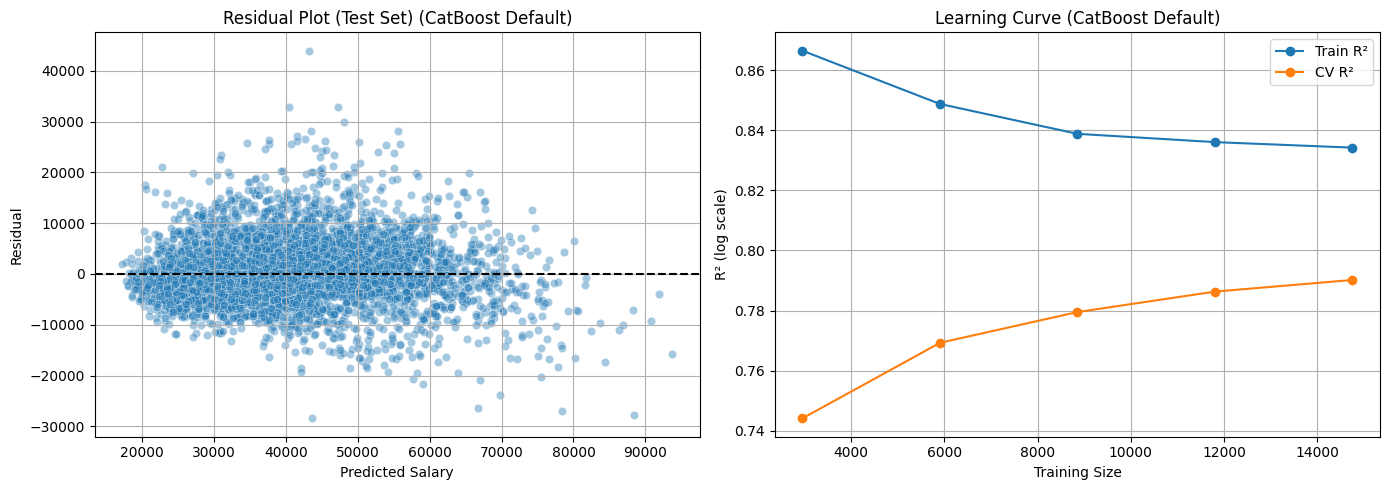

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle
import optuna

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Machine Learning Models
from catboost import CatBoostRegressor

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve


# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

warnings.filterwarnings("ignore")

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]
y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("model", CatBoostRegressor(random_state=42, verbose=False))
])

# CROSS VALIDATION SETUP
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

# RUN CROSS VALIDATION
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'CATBOOST (DEFAULT) - 5-FOLD CV (LOG SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
model.fit(X_train, y_train)

# Predictions (LOG SCALE)
train_pred_log = model.predict(X_train)
test_pred_log  = model.predict(X_test)

# INVERSE TRANSFORM (BACK TO ORIGINAL SALARY)
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT
print("\n" + "="*70)
print(f"{'CATBOOST (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot (ORIGINAL SCALE) ---
residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (CatBoost Default)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

# --- Learning Curve (LOG SCALE) ---
train_sizes, train_scores, val_scores = learning_curve(
    model,                
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(
    train_sizes,
    np.mean(train_scores, axis=1),
    marker='o',
    label="Train R²"
)

axes[1].plot(
    train_sizes,
    np.mean(val_scores, axis=1),
    marker='o',
    label="CV R²"
)

axes[1].grid(True)
axes[1].set_title("Learning Curve (CatBoost Default)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Hyperparameter-tuned CatBoost

[I 2026-05-09 06:20:56,616] A new study created in memory with name: no-name-97837ac3-4901-477b-aeaa-6b7c06fe21bd
[I 2026-05-09 06:25:34,971] Trial 0 finished with value: 0.8067386820458762 and parameters: {'depth': 8, 'l2_leaf_reg': 36.136329681679335, 'random_strength': 5.98304872450394, 'iterations': 2908, 'learning_rate': 0.03601184986705904, 'bagging_temperature': 0.540328577911776, 'border_count': 102}. Best is trial 0 with value: 0.8067386820458762.
[I 2026-05-09 06:30:23,711] Trial 1 finished with value: 0.8097959428405002 and parameters: {'depth': 8, 'l2_leaf_reg': 41.45971674539306, 'random_strength': 4.6004843091864664, 'iterations': 2889, 'learning_rate': 0.04381705918312713, 'bagging_temperature': 0.5126041467133271, 'border_count': 100}. Best is trial 1 with value: 0.8097959428405002.
[I 2026-05-09 06:34:59,317] Trial 2 finished with value: 0.8116900362081918 and parameters: {'depth': 8, 'l2_leaf_reg': 32.21632189472077, 'random_strength': 4.6703105613933875, 'iterations'


 BEST OPTUNA PARAMETERS
depth: 8
l2_leaf_reg: 33.22163601568222
random_strength: 5.378562448547819
iterations: 3092
learning_rate: 0.04999485589950224
bagging_temperature: 0.44030366540837723
border_count: 103

=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.875593  0.817013    0.127082  0.155370   0.091725  0.115101
1     2  0.876248  0.814209    0.126906  0.155760   0.091778  0.114035
2     3  0.876871  0.815690    0.126317  0.156461   0.091418  0.113777
3     4  0.882269  0.798479    0.124570  0.158055   0.089300  0.115550
4     5  0.872914  0.824924    0.128457  0.151919   0.092622  0.111844

               CATBOOST (TUNED) - 5-FOLD CV (LOG SCALE)               
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8768         0.8141         0.0627
RMSE               0.1267         0.1555               
MAE                0

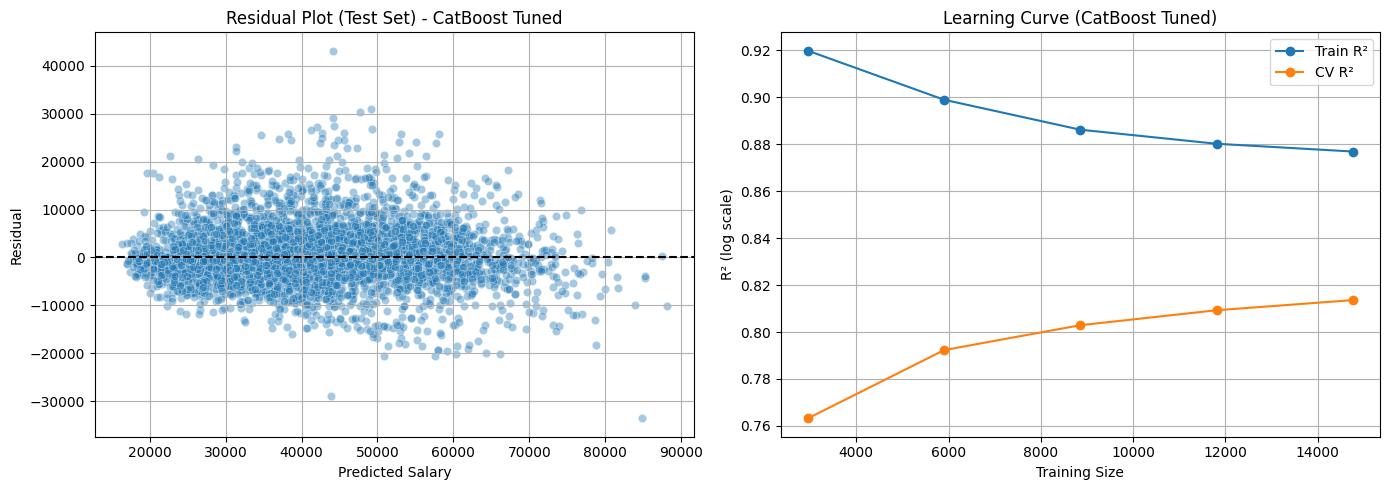

In [ ]:
import random
import warnings
import torch
import pandas as pd
import numpy as np
import pickle
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, make_scorer, mean_squared_error


from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, learning_curve
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    make_scorer
)

# Machine Learning Models
from catboost import CatBoostRegressor


warnings.filterwarnings("ignore")
# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


# SCORERS AND SETUPS
cv = KFold(n_splits=5, shuffle=True, random_state=seed)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error"
}


def rmse_real(y_true, y_pred):
    y_true_real = np.expm1(y_true)
    y_pred_real = np.expm1(y_pred)
    return np.sqrt(mean_squared_error(y_true_real, y_pred_real))

rmse_real_scorer = make_scorer(rmse_real, greater_is_better=False)

# LOAD DATA
df = pd.read_csv(
    "../Unified_Resume_Salary_Dataset.csv"
)

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]

y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)


# OPTUNA OBJECTIVE
def objective(trial):
        
    params = {
        "depth": trial.suggest_int("depth", 6, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 32.0, 55.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 4.0, 6.0),
        "iterations": trial.suggest_int("iterations", 2800, 3100),
        "learning_rate": trial.suggest_float("learning_rate", 0.035, 0.050, log=True),
    
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.35, 0.55),
        "border_count": trial.suggest_int("border_count", 95, 115),

        "random_state": 42,
        "verbose": False
    }

    model = Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_config)),
        ("model", CatBoostRegressor(**params))
    ])
        
    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="r2",
        return_train_score=True,
        n_jobs=1
    )

    score = np.mean(cv_results["test_score"])

    return score


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

best_params = study.best_params

# PRINT BEST PARAMETERS FIRST
print("\n" + "="*80)
print(" BEST OPTUNA PARAMETERS")
print("="*80)
for k, v in best_params.items():
    print(f"{k}: {v}")
print("="*80)

# FINAL MODEL
best_model = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_config)),
    ("model", CatBoostRegressor(
        **best_params,
        random_state=seed,
        verbose=False
    ))
])

# FINAL CV REPORT (STANDARDIZED)
cv_results = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error"
    },
    return_train_score=True,
    n_jobs=-1
)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, cv.get_n_splits() + 1),

    "Train_R2": cv_results["train_r2"],
    "Val_R2": cv_results["test_r2"],

    "Train_RMSE": -cv_results["train_rmse"],
    "Val_RMSE": -cv_results["test_rmse"],

    "Train_MAE": -cv_results["train_mae"],
    "Val_MAE": -cv_results["test_mae"]
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(cv_results["train_r2"])
cv_val_r2   = np.mean(cv_results["test_r2"])

cv_train_rmse = -np.mean(cv_results["train_rmse"])
cv_val_rmse   = -np.mean(cv_results["test_rmse"])

cv_train_mae = -np.mean(cv_results["train_mae"])
cv_val_mae   = -np.mean(cv_results["test_mae"])

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'CATBOOST (TUNED) - 5-FOLD CV (LOG SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
best_model.fit(X_train, y_train)

# PREDICTIONS (LOG SCALE)
train_pred_log = best_model.predict(X_train)
test_pred_log  = best_model.predict(X_test)

# INVERSE TRANSFORM
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT FINAL RESULTS
print("\n" + "="*70)
print(f"{'CATBOOST (TUNED) - TRAIN & TEST (ORIGINAL SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot ---
residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) - CatBoost Tuned")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")

# --- Learning Curve ---
train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

axes[1].plot(train_sizes, np.mean(train_scores, axis=1), marker='o', label="Train R²")
axes[1].plot(train_sizes, np.mean(val_scores, axis=1), marker='o', label="CV R²")

axes[1].grid(True)
axes[1].set_title("Learning Curve (CatBoost Tuned)")
axes[1].set_xlabel("Training Size")
axes[1].set_ylabel("R² (log scale)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Model Export

In [ ]:
from catboost import CatBoostRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import numpy as np
import pandas as pd

# LOAD DATA
df = pd.read_csv(
    "Unified_Resume_Salary_Dataset.csv"
)

with open("master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("train_idx.npy")
test_idx  = np.load("test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"]

X_train = X_text.iloc[train_idx]
X_test  = X_text.iloc[test_idx]

y_train = y.iloc[train_idx].values
y_test  = y.iloc[test_idx].values

# PIPELINE
tfidf_config = dict(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*',
    norm=None,
    binary=True,
    min_df=5
)

tfidf = TfidfVectorizer(**tfidf_config)
X_train_tfidf = tfidf.fit_transform(X_train)

print("Training CatBoost with Optuna best parameters...")
cb_model = CatBoostRegressor(
    depth=8,
    l2_leaf_reg=33.22163601568222,
    random_strength=5.378562448547819,
    iterations=3092,
    learning_rate=0.04999485589950224,
    bagging_temperature=0.44030366540837723,
    border_count=103,
    random_seed=42,
    verbose=0
)

cb_model.fit(X_train_tfidf, y_train)

# Download the tuned model
cb_model.save_model("catboost_salarypred.cbm")
print("Successfully saved: catboost_salarypred.cbm")

Training CatBoost with Optuna best parameters...
Successfully saved: catboost_salarypred.cbm


### Feature Importance

                           Feature  Importance
216              microsoft windows    6.862228
126                         google    4.656603
264                    programming    4.540985
234          operational databases    3.051478
297                        science    2.664163
88                          design    2.480236
274                         python    2.476351
97          education and training    2.288211
99      engineering and technology    2.191746
291            salesforce software    1.951497
199                microsoft excel    1.881749
4                   administrative    1.813554
220                     monitoring    1.628720
3    administration and management    1.599759
116               foreign language    1.580467
172                          linux    1.450571
78                    coordination    1.438158
122                            git    1.424799
290            sales and marketing    1.193131
207           microsoft sql server    1.183021


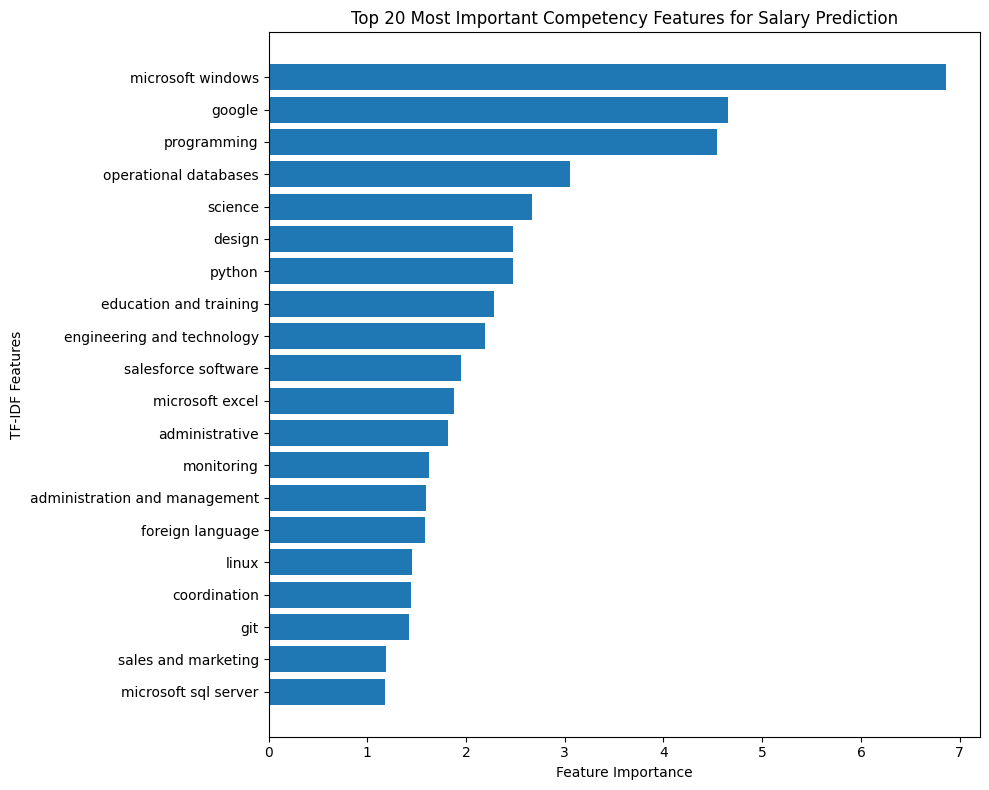

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import Pool

# GET FEATURE IMPORTANCE
feature_importance = cb_model.get_feature_importance()

# TF-IDF feature names
feature_names = tfidf.get_feature_names_out()

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

# SORT TOP FEATURES
top_n = 20

importance_df = (
    importance_df
    .sort_values(by='Importance', ascending=False)
    .head(top_n)
)

print(importance_df)

# BAR CHART
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance'][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("TF-IDF Features")
plt.title(f"Top {top_n} Most Important Competency Features for Salary Prediction")

plt.tight_layout()
plt.show()